# 07. Post-modeling EDA -- disability strand



## 0. Setup

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from pathlib import Path

sns.set_theme(style='whitegrid')
DATA_DIR = Path(r"C:\Users\Lenovo\Documents\GitHub\London-Sport2-Group20\Jingyi Hua\data\processed")
OUTPUT_DIR = Path(r"C:\Users\Lenovo\Documents\GitHub\London-Sport2-Group20\Jingyi Hua\outputs")
FIGURE_DIR = OUTPUT_DIR / 'post_eda_figures'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

summary_all = pd.read_csv(
    OUTPUT_DIR / 'summary_full.csv'
)

validation_summary = summary_all[
    summary_all['split'] == 'validation'
].copy()

test_summary = summary_all[
    summary_all['split'] == 'test'
].copy()

summary = test_summary.copy()
top_activity = pd.read_csv(OUTPUT_DIR / 'top_activity_by_disability_group.csv')

with open(OUTPUT_DIR / 'fitted_models.pkl', 'rb') as f:
    fitted_models = pickle.load(f)
print('fitted models available:', list(fitted_models.keys()))


fitted models available: ['age_overall__Ridge Regression', 'age_overall__Random Forest', 'age_overall__Gradient Boosting', 'dis_overall__Ridge Regression', 'dis_overall__Random Forest', 'dis_overall__Gradient Boosting', 'dis_level__Ridge Regression', 'dis_level__Random Forest', 'dis_level__Gradient Boosting', 'months12__Ridge Regression', 'months12__Random Forest', 'months12__Gradient Boosting', 'days__Ridge Regression', 'days__Random Forest', 'days__Gradient Boosting', 'age_months12__Ridge Regression', 'age_months12__Random Forest', 'age_months12__Gradient Boosting', 'age_days__Ridge Regression', 'age_days__Random Forest', 'age_days__Gradient Boosting', 'age_level__Ridge Regression', 'age_level__Random Forest', 'age_level__Gradient Boosting']


## 1. Model comparison, one panel per task

Covers all 8 tasks (disability strand + age strand).

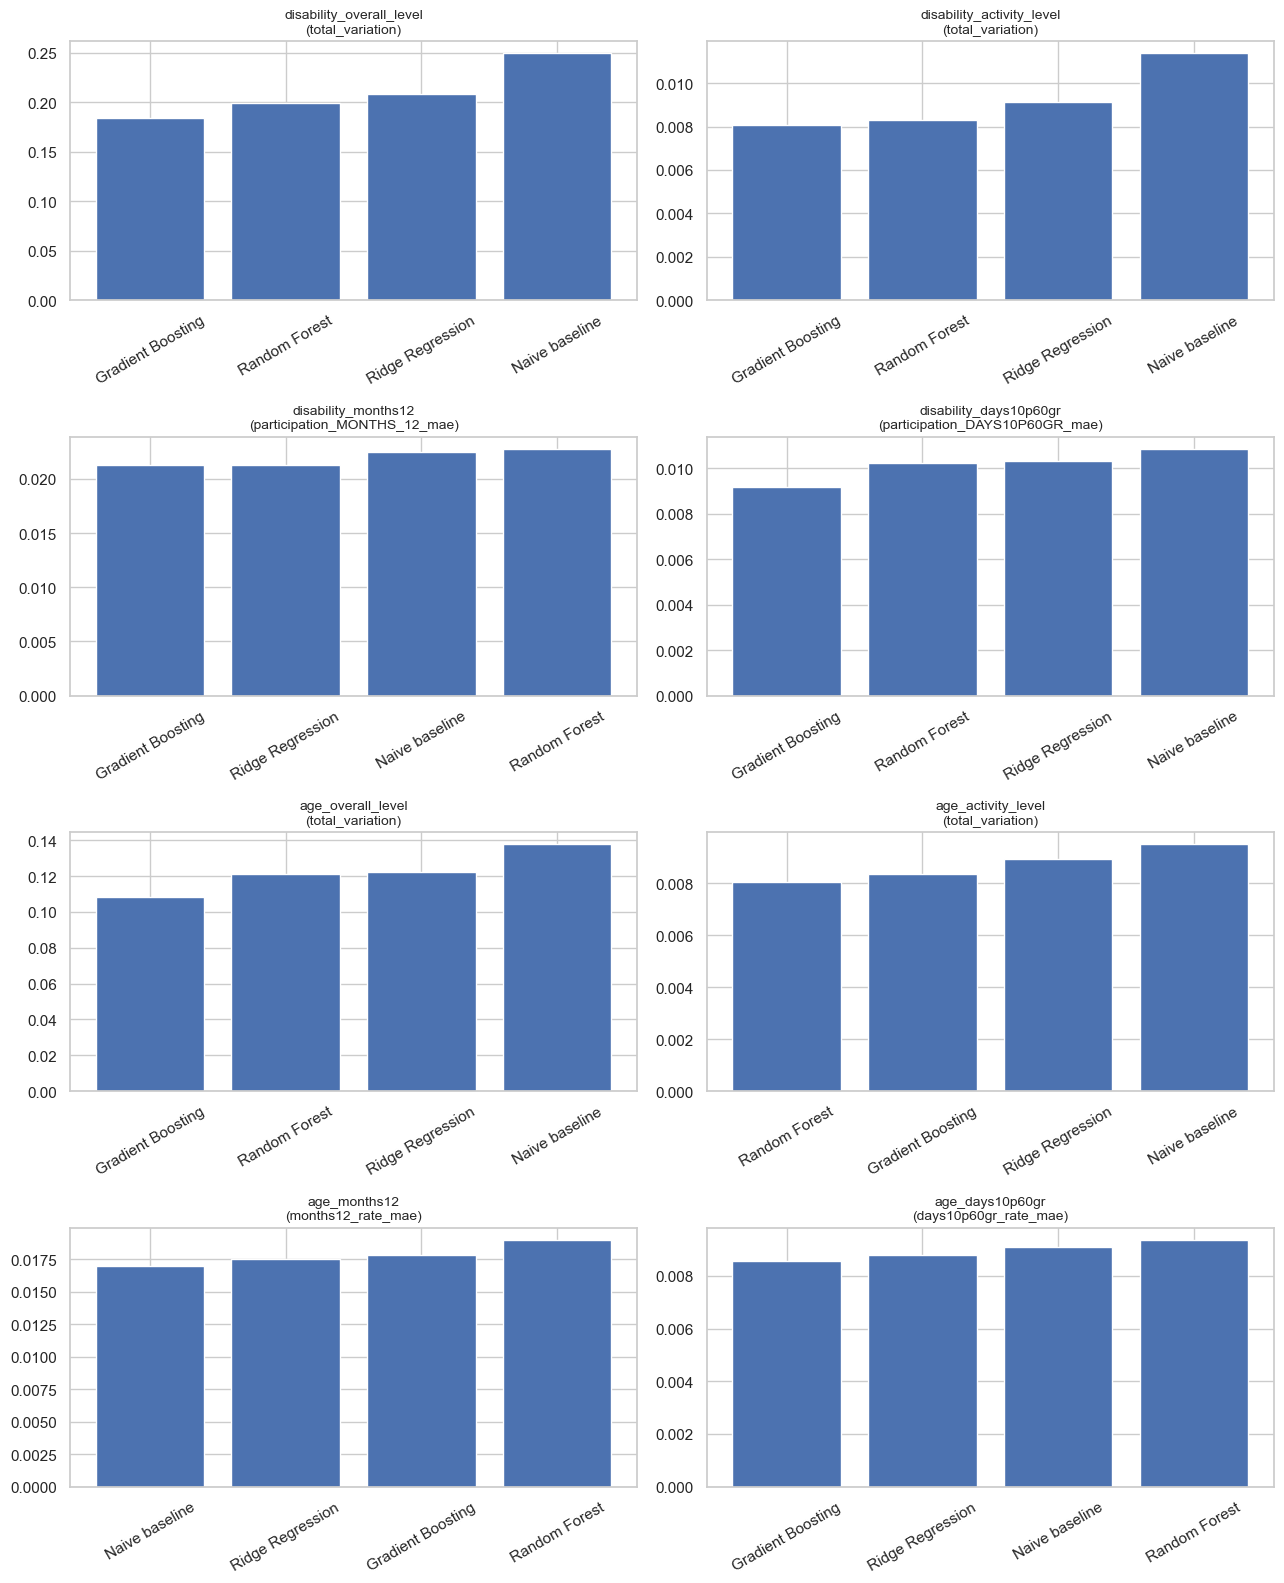

Models selected using validation results:
disability_overall_level : Gradient Boosting
disability_activity_level : Gradient Boosting
disability_months12 : Gradient Boosting
disability_days10p60gr : Gradient Boosting
age_overall_level : Gradient Boosting
age_activity_level : Gradient Boosting
age_months12 : Naive baseline
age_days10p60gr : Ridge Regression


In [3]:
task_primary_metric = {
    'disability_overall_level': 'total_variation',
    'disability_activity_level': 'total_variation',
    'disability_months12': 'participation_MONTHS_12_mae',
    'disability_days10p60gr': 'participation_DAYS10P60GR_mae',
    'age_overall_level': 'total_variation',
    'age_activity_level': 'total_variation',
    'age_months12': 'months12_rate_mae',
    'age_days10p60gr': 'days10p60gr_rate_mae',
}

fig, axes = plt.subplots(4, 2, figsize=(13, 16))
for (task, metric), ax in zip(task_primary_metric.items(), axes.ravel()):
    sub = summary[summary['task'] == task].sort_values(metric)
    ax.bar(sub['model'], sub[metric], color='#4C72B0')
    ax.set_title(f'{task}\n({metric})', fontsize=10)
    ax.tick_params(axis='x', labelrotation=30)

plt.tight_layout()
plt.savefig(FIGURE_DIR / 'figure_01_model_comparison.png', dpi=150)
plt.show()

selected_model_by_task = {}

for task, metric in task_primary_metric.items():
    task_validation = (
        validation_summary[
            validation_summary['task'] == task
        ]
        .dropna(subset=[metric])
    )

    selected_model_by_task[task] = (
        task_validation.loc[
            task_validation[metric].idxmin(),
            'model'
        ]
    )

print('Models selected using validation results:')

for task, model_name in selected_model_by_task.items():
    print(task, ':', model_name)


R2 of the best model per task (best defined by the primary metric above).
This is where the mae/R2 mismatch on age_months12 shows up.


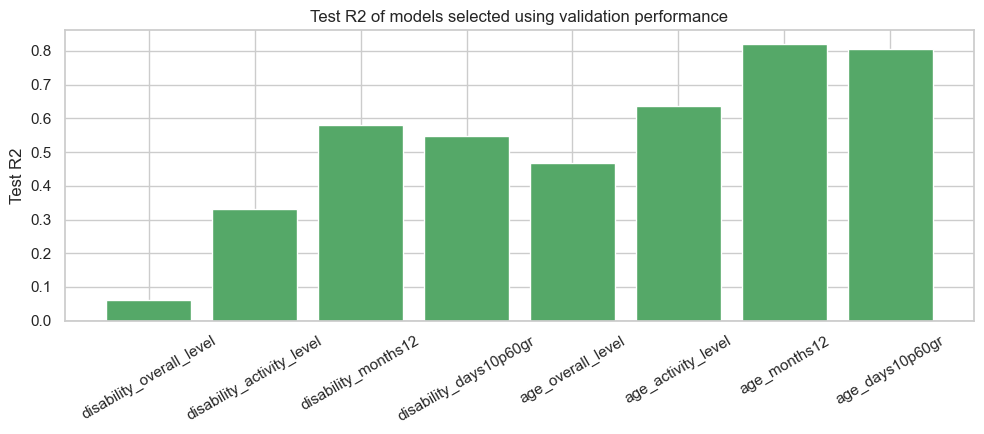

,task,selected_model,selection_metric,test_metric_value,test_r2
0,disability_overall_level,Gradient Boosting,total_variation,0.184113,0.061109
1,disability_activity_level,Gradient Boosting,total_variation,0.007994,0.330611
2,disability_months12,Gradient Boosting,participation_MONTHS_12_mae,0.021148,0.580543
3,disability_days10p60gr,Gradient Boosting,participation_DAYS10P60GR_mae,0.009119,0.547754
4,age_overall_level,Gradient Boosting,total_variation,0.108290,0.468237
5,age_activity_level,Gradient Boosting,total_variation,0.008343,0.635443
6,age_months12,Naive baseline,months12_rate_mae,0.017008,0.819348
7,age_days10p60gr,Ridge Regression,days10p60gr_rate_mae,0.008806,0.805280


In [35]:
best_model_rows = []

for task, metric in task_primary_metric.items():
    selected_model = selected_model_by_task[task]
    r2_col = task_r2_column[task]

    test_row = test_summary[
        (test_summary['task'] == task)
        & (test_summary['model'] == selected_model)
    ].iloc[0]

    best_model_rows.append({
        'task': task,
        'selected_model': selected_model,
        'selection_metric': metric,
        'test_metric_value': test_row[metric],
        'test_r2': test_row[r2_col],
    })

best_model_summary = pd.DataFrame(best_model_rows)

fig, ax = plt.subplots(figsize=(10, 4.5))

colors = [
    '#55A868' if value >= 0 else '#C44E52'
    for value in best_model_summary['test_r2']
]

ax.bar(
    best_model_summary['task'],
    best_model_summary['test_r2'],
    color=colors
)

ax.axhline(
    0,
    color='black',
    linewidth=0.8
)

ax.set_title(
    'Test R2 of models selected using validation performance'
)

ax.set_ylabel('Test R2')
ax.tick_params(axis='x', labelrotation=30)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / 'figure_01b_selected_model_test_r2.png',
    dpi=150
)

plt.show()

best_model_summary

## 1c. Unified model comparison table (MAE, RMSE, R2)



In [36]:
def extract_mae_rmse_r2(row):
    if pd.notna(row.get('overall_mae')):
        mae = row['overall_mae']
        rmse = row['overall_rmse']
    else:
        mae_cols = [c for c in row.index if c.endswith('_mae') and c != 'overall_mae']
        rmse_cols = [c for c in row.index if c.endswith('_rmse') and c != 'overall_rmse']
        mae = row[mae_cols].dropna().mean()
        rmse = row[rmse_cols].dropna().mean()

    r2_cols = [c for c in row.index if c.endswith('_r2')]
    r2 = row[r2_cols].dropna().mean()
    return pd.Series({'MAE': mae, 'RMSE': rmse, 'R2': r2})


comparison_table = summary[['task', 'model']].join(summary.apply(extract_mae_rmse_r2, axis=1))
comparison_table = comparison_table.sort_values(['task', 'MAE']).reset_index(drop=True)
comparison_table


,task,model,MAE,RMSE,R2
0,age_activity_level,Random Forest,0.005355,0.024109,0.634454
1,age_activity_level,Gradient Boosting,0.005562,0.024559,0.622144
2,age_activity_level,Ridge Regression,0.005958,0.026516,0.565675
3,age_activity_level,Naive baseline,0.006328,0.025180,0.555167
4,age_days10p60gr,Gradient Boosting,0.008574,0.028549,0.821145
5,age_days10p60gr,Ridge Regression,0.008806,0.029788,0.805280
6,age_days10p60gr,Naive baseline,0.009106,0.032790,0.764047
7,age_days10p60gr,Random Forest,0.009369,0.027198,0.837664
8,age_months12,Naive baseline,0.017008,0.045394,0.819348
9,age_months12,Ridge Regression,0.017539,0.044093,0.829552


### Per-metric pivot tables (task x model)


In [37]:
mae_pivot = comparison_table.pivot(index='task', columns='model', values='MAE')
rmse_pivot = comparison_table.pivot(index='task', columns='model', values='RMSE')
r2_pivot = comparison_table.pivot(index='task', columns='model', values='R2')

print('--- MAE (lower is better) ---')
print(mae_pivot.round(4))
print()
print('--- RMSE (lower is better) ---')
print(rmse_pivot.round(4))
print()
print('--- R2 (higher is better) ---')
print(r2_pivot.round(4))


--- MAE (lower is better) ---
model                      Gradient Boosting  Naive baseline  Random Forest  \
task                                                                          
age_activity_level                    0.0056          0.0063         0.0054   
age_days10p60gr                       0.0086          0.0091         0.0094   
age_months12                          0.0179          0.0170         0.0190   
age_overall_level                     0.0722          0.0918         0.0807   
disability_activity_level             0.0053          0.0075         0.0055   
disability_days10p60gr                0.0091          0.0108         0.0102   
disability_months12                   0.0211          0.0223         0.0225   
disability_overall_level              0.1227          0.1662         0.1331   

model                      Ridge Regression  
task                                         
age_activity_level                   0.0060  
age_days10p60gr                      0.00

### Best model per task, checked against more than one metric

Best-by-MAE and best-by-R2 are found independently for every task.

In [38]:
for task in comparison_table['task'].unique():
    sub = comparison_table[comparison_table['task'] == task]
    best_by_mae = sub.loc[sub['MAE'].idxmin(), 'model']
    best_by_rmse = sub.loc[sub['RMSE'].idxmin(), 'model']
    best_by_r2 = sub.loc[sub['R2'].idxmax(), 'model']

    agree = (best_by_mae == best_by_rmse == best_by_r2)
    flag = '' if agree else '  <-- metrics disagree, needs a written justification'
    print(f'{task}: best by MAE={best_by_mae}, best by RMSE={best_by_rmse}, best by R2={best_by_r2}{flag}')


age_activity_level: best by MAE=Random Forest, best by RMSE=Random Forest, best by R2=Random Forest
age_days10p60gr: best by MAE=Gradient Boosting, best by RMSE=Random Forest, best by R2=Random Forest  <-- metrics disagree, needs a written justification
age_months12: best by MAE=Naive baseline, best by RMSE=Random Forest, best by R2=Random Forest  <-- metrics disagree, needs a written justification
age_overall_level: best by MAE=Gradient Boosting, best by RMSE=Gradient Boosting, best by R2=Gradient Boosting
disability_activity_level: best by MAE=Gradient Boosting, best by RMSE=Gradient Boosting, best by R2=Gradient Boosting
disability_days10p60gr: best by MAE=Gradient Boosting, best by RMSE=Random Forest, best by R2=Random Forest  <-- metrics disagree, needs a written justification
disability_months12: best by MAE=Gradient Boosting, best by RMSE=Random Forest, best by R2=Random Forest  <-- metrics disagree, needs a written justification
disability_overall_level: best by MAE=Gradient Bo

## 2. Prediction error by borough



In [4]:
def add_lag_features(frame, panel_keys, value_cols, lags=(1,),
                     rolling_window=None, covid_years=(5, 6)):
    prepared = frame.sort_values(
        panel_keys + ['year']
    ).reset_index(drop=True)

    grouped = prepared.groupby(
        panel_keys,
        sort=False
    )

    for column in value_cols:
        for lag in lags:
            prepared[f'{column}_lag{lag}'] = (
                grouped[column].shift(lag)
            )

        if rolling_window:
            prepared[f'{column}_roll{rolling_window}'] = (
                grouped[column].transform(
                    lambda s: s.shift(1).rolling(
                        rolling_window,
                        min_periods=1
                    ).mean()
                )
            )

    prepared['time_trend'] = (
        prepared['year']
        / prepared['year'].max()
    )

    prepared['is_covid_year'] = (
        prepared['year']
        .isin(covid_years)
        .astype(int)
    )

    return prepared


def alr_to_shares(values):
    values = np.clip(
        np.asarray(values, dtype=float),
        -30,
        30
    )

    exponent = np.exp(values)

    denominator = (
        1
        + exponent.sum(
            axis=1,
            keepdims=True
        )
    )

    return np.column_stack([
        exponent / denominator,
        1 / denominator
    ])


dis_level = pd.read_csv(
    DATA_DIR
    / 'RQ3_borough_disability_MEMS7GR_all_years.csv'
)

dis_level['LA_2023'] = (
    dis_level['LA_2023']
    .astype('Int64')
    .astype(str)
)

target_cols = [
    'inactive_rate',
    'fairly_active_rate',
    'active_rate'
]

panel_keys = [
    'LA_2023',
    'disability_group',
    'activity'
]

prepared = add_lag_features(
    dis_level,
    panel_keys,
    target_cols,
    lags=(1,),
    rolling_window=2
)

lag1_cols = [
    f'{column}_lag1'
    for column in target_cols
]

rolling_cols = [
    f'{column}_roll2'
    for column in target_cols
]

lag_cols = (
    lag1_cols
    + rolling_cols
)

selected_dis_level_model = (
    selected_model_by_task[
        'disability_activity_level'
    ]
)

if selected_dis_level_model == 'Ridge Regression':
    interaction_dummies = pd.get_dummies(
        prepared['disability_group'],
        prefix='disability_group_x_time'
    )

    interaction_cols = list(
        interaction_dummies.columns
    )

    prepared[interaction_cols] = (
        interaction_dummies.mul(
            prepared['time_trend'],
            axis=0
        )
    )

test = (
    prepared[
        prepared['year'] == 8
    ]
    .dropna(
        subset=target_cols + lag_cols
    )
    .copy()
)

if selected_dis_level_model == 'Naive baseline':
    predicted_shares = (
        test[lag1_cols].to_numpy()
    )

else:
    best_model = fitted_models[
        f'dis_level__{selected_dis_level_model}'
    ]

    model_features = list(
        best_model.feature_names_in_
    )

    predicted_shares = alr_to_shares(
        best_model.predict(
            test[model_features]
        )
    )

test['predicted_active_rate'] = (
    predicted_shares[:, 2]
)

test['abs_error'] = (
    test['active_rate']
    - test['predicted_active_rate']
).abs()

print(
    'Model used for subgroup error analysis:',
    selected_dis_level_model
)

Model used for subgroup error analysis: Gradient Boosting


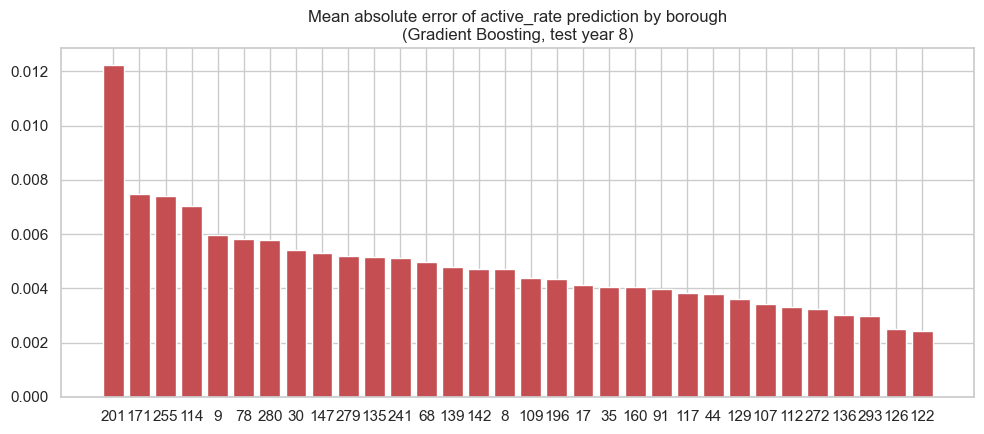

Boroughs with the largest prediction error:
LA_2023
201    0.012245
171    0.007488
255    0.007416
114    0.007031
9      0.005976
Name: abs_error, dtype: float64


In [5]:
error_by_borough = test.groupby('LA_2023')['abs_error'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.bar(error_by_borough.index.astype(str), error_by_borough.values, color='#C44E52')
ax.set_title(
    f'Mean absolute error of active_rate prediction by borough\n'
    f'({selected_dis_level_model}, test year 8)'
)
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'figure_02_error_by_borough.png', dpi=150)
plt.show()

print('Boroughs with the largest prediction error:')
print(error_by_borough.head(5))


In [6]:
test["sample_size_group"] = np.where(test["n"] < 30, "n < 30", "n >= 30")

small_sample_error = test.groupby("sample_size_group").agg(
    cells=("abs_error", "size"),
    mean_mae=("abs_error", "mean"),
    median_mae=("abs_error", "median"),
    rmse=("abs_error", lambda x: np.sqrt(np.mean(x ** 2))),
    mean_observed_rate=("active_rate", "mean"),
    zero_rate=("active_rate", lambda x: (x == 0).mean())
).reset_index()

positive_sample_error = test[test["active_rate"] > 0].groupby("sample_size_group").agg(
    positive_cells=("abs_error", "size"),
    positive_cell_mae=("abs_error", "mean")
).reset_index()

small_sample_error = small_sample_error.merge(positive_sample_error, on="sample_size_group", how="left")

print("Overall Year 8 active-rate MAE:", round(test["abs_error"].mean(), 4))
print("Positive-cell Year 8 active-rate MAE:", round(test.loc[test["active_rate"] > 0, "abs_error"].mean(), 4))
print(small_sample_error.round(4).to_string(index=False))

small_sample_error.to_csv(OUTPUT_DIR / "year8_activity_level_error_by_raw_sample_size.csv", index=False)

Overall Year 8 active-rate MAE: 0.0048
Positive-cell Year 8 active-rate MAE: 0.0693
sample_size_group  cells  mean_mae  median_mae   rmse  mean_observed_rate  zero_rate  positive_cells  positive_cell_mae
           n < 30  42560    0.0049         0.0 0.0385              0.0056     0.9699            1282             0.1539
          n >= 30  19832    0.0046         0.0 0.0203              0.0082     0.8550            2875             0.0316


## 3. Prediction error by disability group


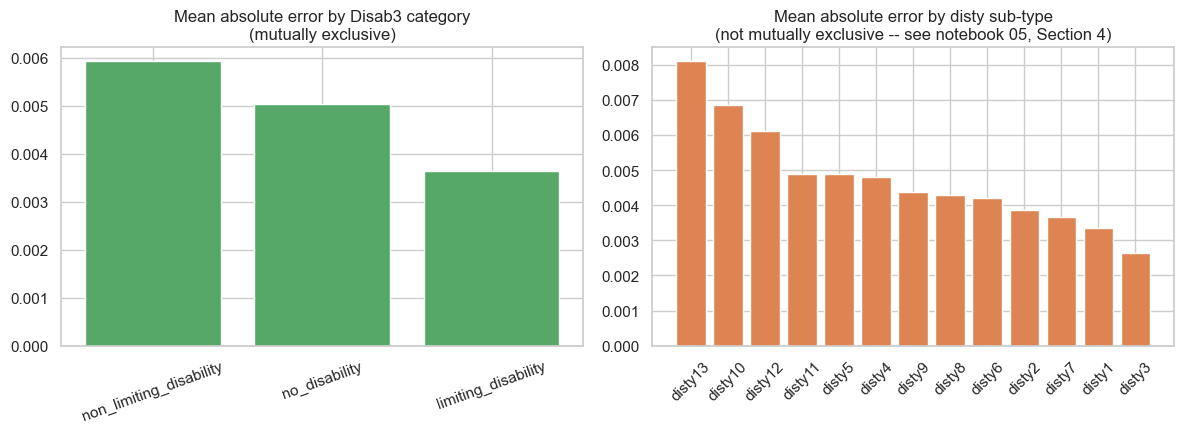

In [40]:
disab3_labels = {'limiting_disability', 'non_limiting_disability', 'no_disability'}
disty_labels = {f'disty{i}' for i in range(1, 14)}

error_by_group = test.groupby('disability_group')['abs_error'].mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

disab3_error = error_by_group[error_by_group.index.isin(disab3_labels)].sort_values(ascending=False)
axes[0].bar(disab3_error.index, disab3_error.values, color='#55A868')
axes[0].set_title('Mean absolute error by Disab3 category\n(mutually exclusive)')
axes[0].tick_params(axis='x', labelrotation=20)

disty_error = error_by_group[error_by_group.index.isin(disty_labels)].sort_values(ascending=False)
axes[1].bar(disty_error.index, disty_error.values, color='#DD8452')
axes[1].set_title('Mean absolute error by disty sub-type\n(not mutually exclusive -- see notebook 05, Section 4)')
axes[1].tick_params(axis='x', labelrotation=45)

plt.tight_layout()
plt.savefig(FIGURE_DIR / 'figure_03_error_by_disability_group.png', dpi=150)
plt.show()


## 4. Overall-level table vs activity-specific table


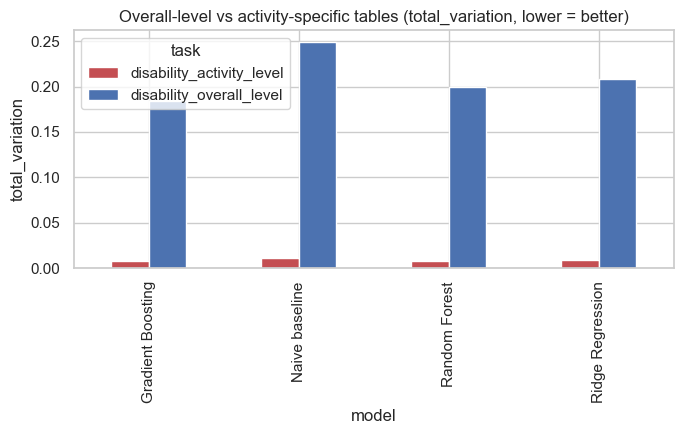

task               disability_activity_level  disability_overall_level
model                                                                 
Gradient Boosting                   0.007994                  0.184113
Naive baseline                      0.011291                  0.249353
Random Forest                       0.008222                  0.199677
Ridge Regression                    0.009081                  0.207858


In [41]:
compare_tasks = summary[summary['task'].isin(['disability_overall_level', 'disability_activity_level'])]
pivot = compare_tasks.pivot(index='model', columns='task', values='total_variation')

fig, ax = plt.subplots(figsize=(7, 4.5))
pivot.plot(kind='bar', ax=ax, color=['#C44E52', '#4C72B0'])
ax.set_title('Overall-level vs activity-specific tables (total_variation, lower = better)')
ax.set_ylabel('total_variation')
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'figure_04_overall_vs_activity_level.png', dpi=150)
plt.show()

print(pivot)


## 5. Highest predicted participation activity across boroughs and groups

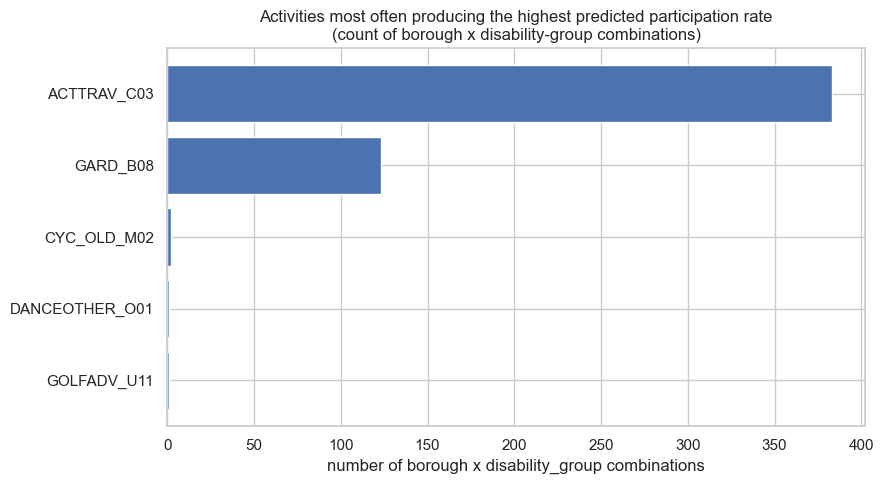

activity
ACTTRAV_C03       383
GARD_B08          123
CYC_OLD_M02         2
DANCEOTHER_O01      1
GOLFADV_U11         1
Name: count, dtype: int64


In [42]:
activity_win_counts = top_activity['activity'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(activity_win_counts.index[::-1], activity_win_counts.values[::-1], color='#4C72B0')
ax.set_title(
    'Activities most often producing the highest predicted participation rate\n'
    '(count of borough x disability-group combinations)'
)
ax.set_xlabel('number of borough x disability_group combinations')
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'figure_05_top_activity_distribution.png', dpi=150)
plt.show()

print(activity_win_counts)


## 6. Subgroup error diagnostics

In [43]:
borough_error_summary = (
    test.assign(
        squared_error=(
            test['active_rate']
            - test['predicted_active_rate']
        ) ** 2,
        observed_zero=(
            test['active_rate'] == 0
        ).astype(int)
    )
    .groupby('LA_2023')
    .agg(
        mean_absolute_error=('abs_error', 'mean'),
        median_absolute_error=('abs_error', 'median'),
        rmse=('squared_error', lambda x: np.sqrt(x.mean())),
        observed_zero_share=('observed_zero', 'mean'),
        number_of_cells=('abs_error', 'size')
    )
    .sort_values('mean_absolute_error', ascending=False)
)

print('Borough-level error summary:')
print(borough_error_summary.round(6))

print()
print('Five boroughs with the highest mean absolute error:')
print(borough_error_summary.head(5).round(6))

borough_mae_range = (
    borough_error_summary['mean_absolute_error'].max()
    - borough_error_summary['mean_absolute_error'].min()
)

print()
print('Range of borough-level mean absolute error:', round(borough_mae_range, 6))

Borough-level error summary:
         mean_absolute_error  median_absolute_error      rmse  \
LA_2023                                                         
201                 0.012151               0.000001  0.071281   
171                 0.007396               0.000001  0.044484   
255                 0.007395               0.000001  0.049380   
114                 0.006982               0.000001  0.039715   
9                   0.005940               0.000001  0.033764   
78                  0.005794               0.000001  0.035894   
280                 0.005750               0.000001  0.036256   
30                  0.005364               0.000001  0.046765   
147                 0.005268               0.000001  0.029236   
279                 0.005203               0.000001  0.037089   
135                 0.005162               0.000001  0.036581   
241                 0.005054               0.000001  0.032856   
68                  0.004934               0.000001  0.031677

In [44]:
from scipy import stats

paired_group_error = (
    test[
        test['disability_group'].isin([
            'limiting_disability',
            'non_limiting_disability'
        ])
    ]
    .groupby(['LA_2023', 'disability_group'])['abs_error']
    .mean()
    .unstack('disability_group')
    .dropna()
)

paired_group_error['paired_difference'] = (
    paired_group_error['non_limiting_disability']
    - paired_group_error['limiting_disability']
)

wilcoxon_result = stats.wilcoxon(
    paired_group_error['non_limiting_disability'],
    paired_group_error['limiting_disability'],
    alternative='two-sided'
)

print('Number of paired boroughs:', len(paired_group_error))
print(
    'Median borough-level MAE, non-limiting disability:',
    paired_group_error['non_limiting_disability'].median()
)
print(
    'Median borough-level MAE, limiting disability:',
    paired_group_error['limiting_disability'].median()
)
print(
    'Median paired difference:',
    paired_group_error['paired_difference'].median()
)
print(
    'Wilcoxon signed-rank p-value:',
    wilcoxon_result.pvalue
)

paired_group_error.head()

Number of paired boroughs: 32
Median borough-level MAE, non-limiting disability: 0.006065575868183256
Median borough-level MAE, limiting disability: 0.0035932658060315492
Median paired difference: 0.00232782119826059
Wilcoxon signed-rank p-value: 4.397472366690636e-05


disability_group,limiting_disability,non_limiting_disability,paired_difference
LA_2023,,,
107,0.002737,0.005158,0.002422
109,0.002271,0.008061,0.005790
112,0.002775,0.004465,0.001691
114,0.008241,0.006441,-0.001800
117,0.001453,0.002416,0.000963


In [45]:
positive_rate_test = test[
    test['active_rate'] > 0
].copy()

positive_cell_error = (
    positive_rate_test
    .groupby('disability_group')['abs_error']
    .agg(
        mean_absolute_error='mean',
        median_absolute_error='median',
        number_of_cells='size'
    )
    .sort_values('mean_absolute_error', ascending=False)
)

zero_cell_share = 1 - (
    len(positive_rate_test) / len(test)
)

print('Share of test cells with observed active_rate = 0:', round(zero_cell_share, 4))
print()
print('Error among cells with observed active_rate > 0:')
print(positive_cell_error.round(6))

Share of test cells with observed active_rate = 0: 0.9339

Error among cells with observed active_rate > 0:
                         mean_absolute_error  median_absolute_error  \
disability_group                                                      
disty11                             0.309229               0.263694   
disty13                             0.306182               0.255498   
disty10                             0.282083               0.245119   
disty6                              0.228989               0.185211   
disty9                              0.187384               0.160936   
disty12                             0.152287               0.112427   
disty4                              0.136017               0.110797   
disty8                              0.132830               0.093231   
disty7                              0.089837               0.059142   
disty5                              0.069311               0.048717   
disty2                              0.06

## 7. Exploratory feature importance for tree-based models

The activity-level test data contain many cells where the observed
`active_rate` is zero. Predictions for these cells are often close to the
minimum positive value created by the ALR transformation, so their absolute
errors are concentrated near zero.

Errors are also clustered within boroughs, disability groups and activities.
Borough differences are therefore reported descriptively. The comparison
between limiting and non-limiting disability uses borough-level paired mean
absolute errors, with one value per disability category in each borough.
This reduces, but does not fully remove, dependence between observations, so
the test is treated as exploratory.

In [46]:
from sklearn.multioutput import MultiOutputRegressor


def get_feature_importance(fitted_model, top_n=15):
    preprocess = fitted_model.named_steps['preprocess']
    model = fitted_model.named_steps['model']
    feature_names = preprocess.get_feature_names_out()

    if isinstance(model, MultiOutputRegressor):
        per_target = np.array([est.feature_importances_ for est in model.estimators_])
        importances = per_target.mean(axis=0)
    else:
        importances = model.feature_importances_

    series = pd.Series(importances, index=feature_names)
    return series.sort_values(ascending=False).head(top_n)


def plot_feature_importance(ax, fitted_model, title):
    top = get_feature_importance(fitted_model)
    ax.barh(top.index[::-1], top.values[::-1], color='#4C72B0')
    ax.set_title(title, fontsize=9)
    ax.tick_params(axis='y', labelsize=7)


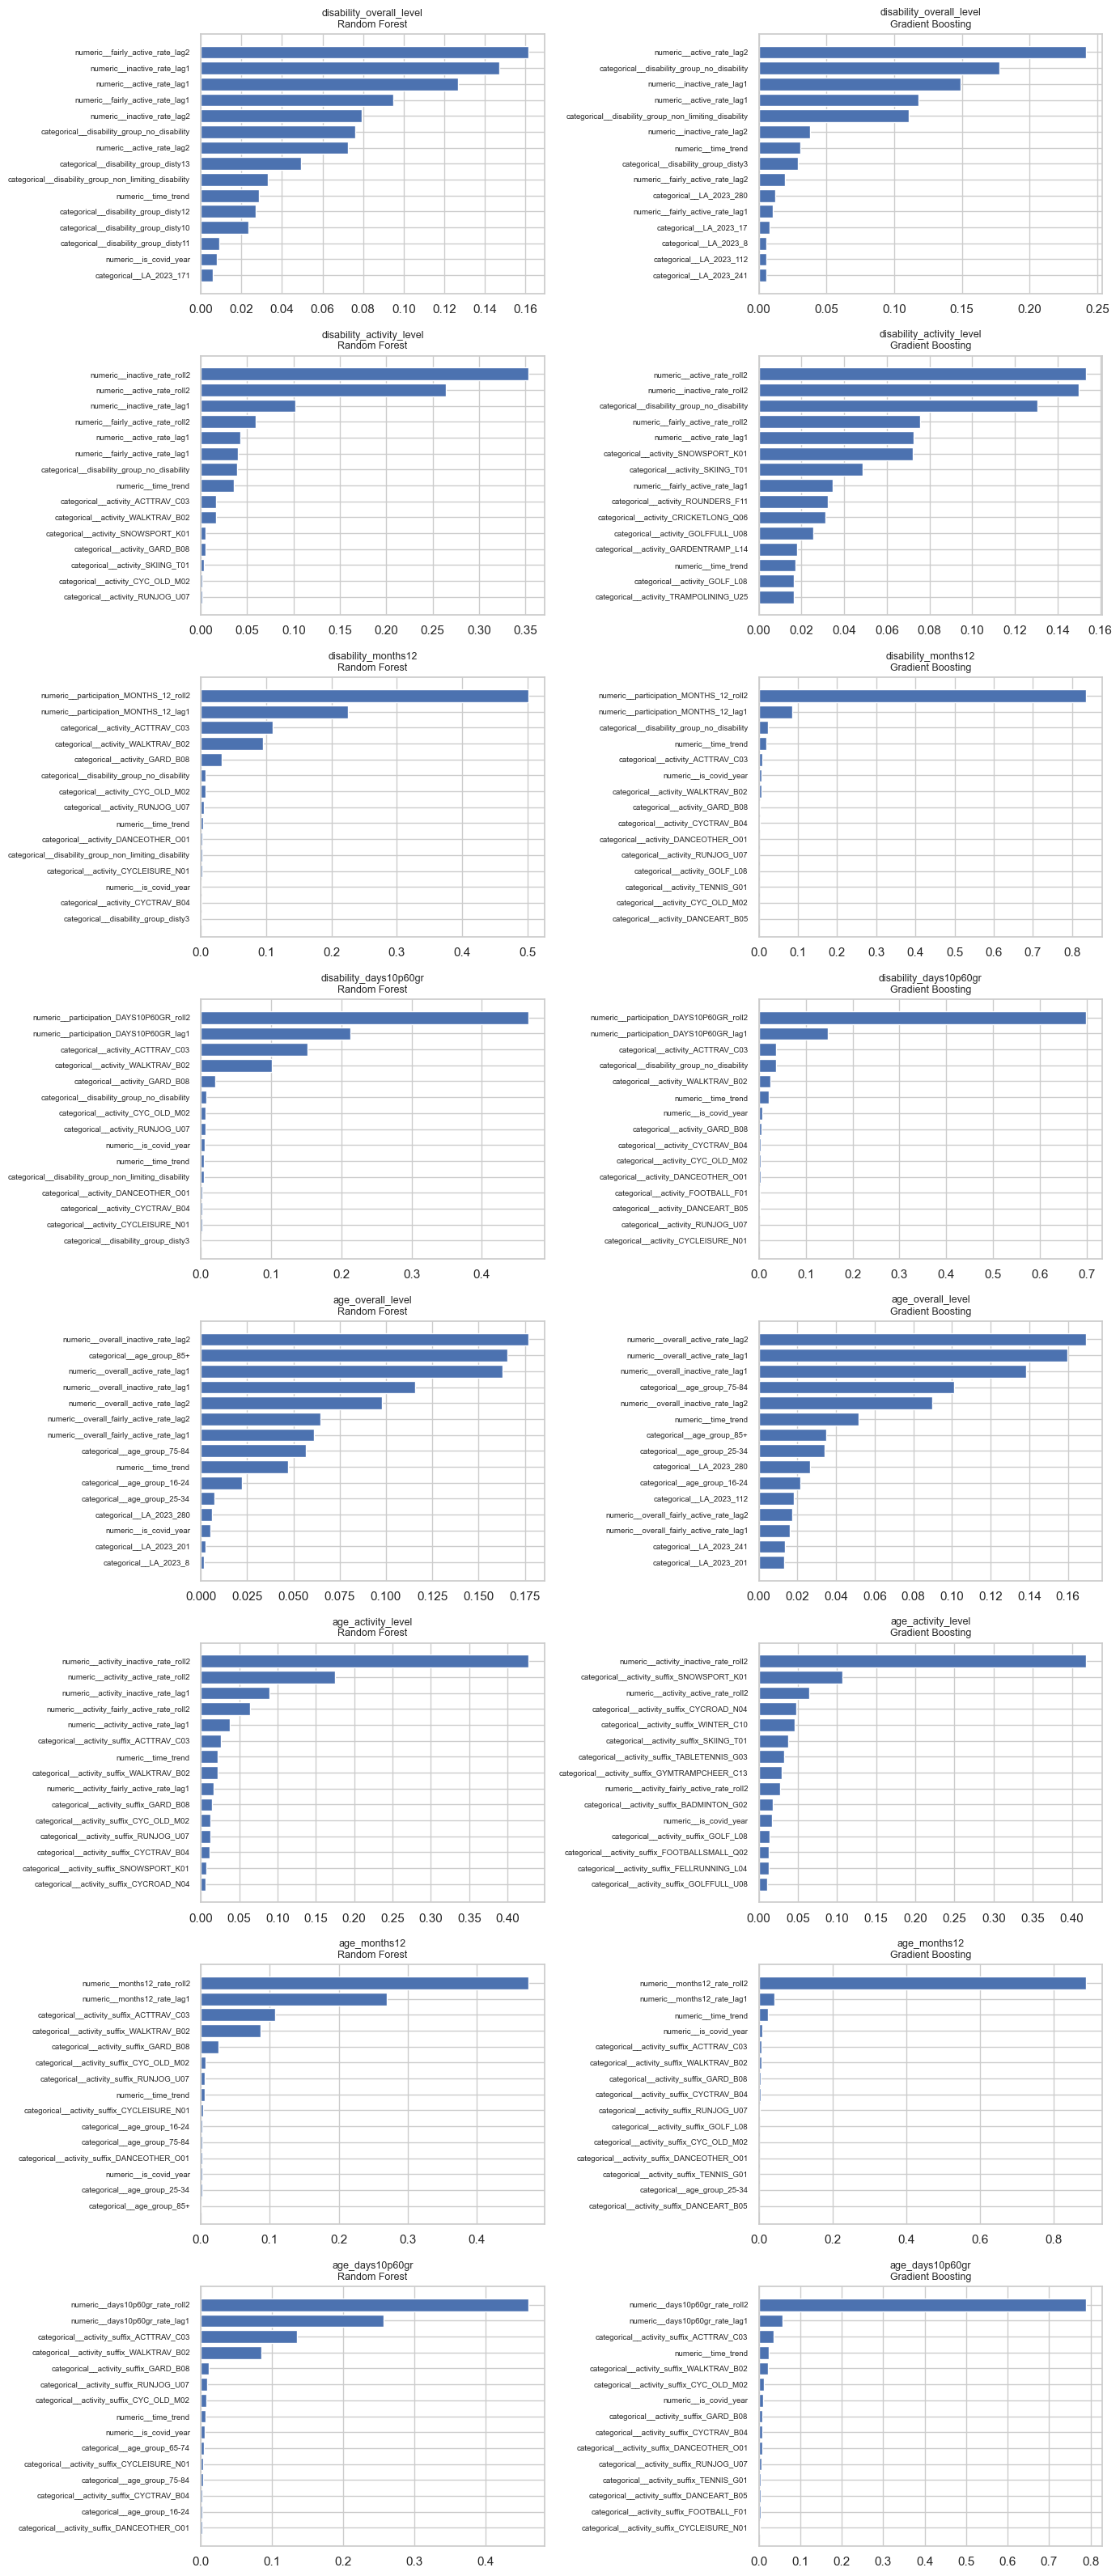

In [50]:
task_model_prefix = {
    'disability_overall_level': 'dis_overall',
    'disability_activity_level': 'dis_level',
    'disability_months12': 'months12',
    'disability_days10p60gr': 'days',
    'age_overall_level': 'age_overall',
    'age_activity_level': 'age_level',
    'age_months12': 'age_months12',
    'age_days10p60gr': 'age_days',
}

tree_model_names = [
    'Random Forest',
    'Gradient Boosting'
]

n_tasks = len(task_model_prefix)

fig, axes = plt.subplots(
    n_tasks,
    2,
    figsize=(14, 4 * n_tasks)
)

for row, (task_name, key_prefix) in enumerate(
    task_model_prefix.items()
):
    for col, model_name in enumerate(
        tree_model_names
    ):
        ax = axes[row, col]

        fitted_model = fitted_models[
            f'{key_prefix}__{model_name}'
        ]

        plot_feature_importance(
            ax,
            fitted_model,
            title=f'{task_name}\n{model_name}'
        )

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / 'figure_06_tree_model_feature_importance.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()